# Ultimate Tic-Tac-Toe — Evaluation AI (ResNet Policy-Value Network)

## Architecture Choisie : Dual-Head ResNet (inspiré d'AlphaZero)

### Pourquoi ce choix ?
Le dataset `u3t` contient pour chaque état :
- `state` (string 90 chars) : plateau + méta-infos encodées
- `num_visits`, `num_wins`, `num_draws`, `num_losses` : statistiques MCTS
- `actions` : liste des coups légaux avec stats MCTS par coup

**Cible principale :** Value head → score W/(W+L) (win-rate normalisé depuis la perspective du joueur courant)

**Cible secondaire :** Policy head → distribution de probabilité sur les 81 cases (softmax sur les Q-values des actions)

### Structure du réseau
```
Input (batch, 18, 9, 9)  ← 18 plans binaires (encoding AlphaZero-style)
    │
    ▼
Conv2D(256, 3x3) + BN + ReLU  ← Stem
    │
    ▼
ResBlock x 10  (256 filtres, skip connections)
    │
   ┌┴────────────────┐
   ▼                 ▼
Policy Head        Value Head
Conv(2,1x1)        Conv(1,1x1)
BN+ReLU            BN+ReLU
Flatten            Flatten
Linear(81)         Linear(256)
Softmax            ReLU
                   Linear(1)
                   Tanh → [-1, 1]
```

### Encoding de l'état (18 plans 9×9)
- Plans 0-8 : cases occupées par joueur 1 (une case par sous-grille)
- Plans 9-17 : cases occupées par joueur 2
- Plan meta-board : état des 9 grandes cases (gagné/perdu/nul)
- Plan active_board : quelle sous-grille est active (ou toutes si libre)
- Plan turn : 1 si c'est le tour du joueur 1, 0 sinon (broadcast)

### Loss
```
L_total = L_value + λ * L_policy
L_value  = MSE(v_pred, z)          z = (wins - losses) / visits ∈ [-1,1]
L_policy = CrossEntropy(π_pred, π_target)  π_target = softmax des Q(a) MCTS
```

In [1]:
# ============================================================
# 1. IMPORTS & CONFIGURATION
# ============================================================
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from datasets import load_dataset
from tqdm.auto import tqdm

# ── Device ──────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Hyper-paramètres ────────────────────────────────────────
CFG = dict(
    # Réseau
    in_channels      = 20,    # 18 plans jeu + plan active_board + plan turn
    num_filters      = 256,
    num_res_blocks   = 10,
    policy_size      = 81,    # 9×9 coups possibles
    # Entraînement
    batch_size       = 1024,
    lr               = 1e-3,
    weight_decay     = 1e-4,
    epochs           = 15,
    lambda_policy    = 1.0,   # poids de la policy loss
    # Données
    min_visits       = 100,   # filtre les états sous-échantillonnés
    max_train_samples= 1_000_000,  # sous-échantillonnage si nécessaire
    seed             = 42,
)
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

Device : cuda
GPU     : Tesla P100-PCIE-16GB
VRAM    : 17.1 GB


In [2]:
# ============================================================
# 2. CHARGEMENT DU DATASET DEPUIS HUGGING FACE
# ============================================================
print("Chargement du dataset u3t (markstanl/u3t)...")
raw = load_dataset("markstanl/u3t", trust_remote_code=True)
print(raw)
print(f"\nColonnes : {raw['train'].column_names}")
print(f"Exemple  :\n{raw['train'][0]}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'markstanl/u3t' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Chargement du dataset u3t (markstanl/u3t)...


README.md: 0.00B [00:00, ?B/s]

data/full_dataset/train.parquet:   0%|          | 0.00/883M [00:00<?, ?B/s]

data/full_dataset/test.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

data/full_dataset/validation.parquet:   0%|          | 0.00/126M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5601458 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1600367 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/800165 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['state', 'num_visits', 'num_wins', 'num_draws', 'num_losses', 'actions', 'depth'],
        num_rows: 5601458
    })
    test: Dataset({
        features: ['state', 'num_visits', 'num_wins', 'num_draws', 'num_losses', 'actions', 'depth'],
        num_rows: 1600367
    })
    validation: Dataset({
        features: ['state', 'num_visits', 'num_wins', 'num_draws', 'num_losses', 'actions', 'depth'],
        num_rows: 800165
    })
})

Colonnes : ['state', 'num_visits', 'num_wins', 'num_draws', 'num_losses', 'actions', 'depth']
Exemple  :
{'state': '000000000000100000200000000000000020000010000020200020100000000001001000000001200000000000120', 'num_visits': 2000000, 'num_wins': 910528, 'num_draws': 393269, 'num_losses': 696203, 'actions': [{'index': 24, 'num_draws': 34719, 'num_losses': 12185, 'num_wins': 75038, 'symbol': 1}, {'index': 25, 'num_draws': 100034, 'num_losses': 41035, 'num_wins': 219386, 'symbol': 1}, {'index': 16, 'num_draw

In [3]:
# ============================================================
# 3. ENCODING DE L'ETAT (corrige : strings de 93 chars)
# ============================================================
# Format state string (93 chars):
#   s[0:81]  -> plateau principal  (0=vide, 1=joueur1, 2=joueur2)
#   s[81:90] -> meta-board (etat des 9 sous-grilles)
#   s[90]    -> active board index (0-8, ou autre si toutes libres)
#   s[91]    -> current player (1 ou 2)
#   s[92]    -> profondeur (ignoree)

def decode_state_string(s):
    n = len(s)
    assert n >= 81, f'String trop courte : {n} chars'

    board      = np.array([int(c) for c in s[0:81]], dtype=np.int8)
    meta_board = np.array([int(c) for c in s[81:90]], dtype=np.int8) if n >= 90 else np.zeros(9, dtype=np.int8)

    # Active board index (s[90])
    if n >= 91:
        raw_active = int(s[90])
        active_idx = raw_active if 0 <= raw_active <= 8 else -1
    else:
        active_idx = -1

    # Current player (s[91])
    current_player = None
    if n >= 92:
        cp = int(s[91])
        current_player = cp if cp in (1, 2) else None

    # Fallback : deduire depuis la parite des coups joues
    if current_player not in (1, 2):
        n_p1 = int((board == 1).sum())
        n_p2 = int((board == 2).sum())
        current_player = 1 if n_p1 == n_p2 else 2

    return board, meta_board, active_idx, current_player


def state_to_tensor(s):
    board, meta_board, active_idx, current_player = decode_state_string(s)
    tensor = np.zeros((20, 9, 9), dtype=np.float32)

    for sub in range(9):
        r_sub, c_sub = divmod(sub, 3)
        for cell in range(9):
            r_cell, c_cell = divmod(cell, 3)
            board_idx = sub * 9 + cell
            row = r_sub * 3 + r_cell
            col = c_sub * 3 + c_cell
            val = board[board_idx]
            if val == 1:
                tensor[sub, row, col] = 1.0
            elif val == 2:
                tensor[sub + 9, row, col] = 1.0

    if active_idx == -1:
        tensor[18] = 1.0
    else:
        r_sub, c_sub = divmod(active_idx, 3)
        for cell in range(9):
            r_cell, c_cell = divmod(cell, 3)
            tensor[18, r_sub * 3 + r_cell, c_sub * 3 + c_cell] = 1.0

    tensor[19] = float(current_player == 1)
    return tensor


def compute_value_target(row):
    w, l, v = row['num_wins'], row['num_losses'], row['num_visits']
    if v == 0:
        return 0.0
    return float(w - l) / float(v)


def compute_policy_target(actions, policy_size=81):
    pi = np.zeros(policy_size, dtype=np.float32)
    if not actions:
        return pi
    for act in actions:
        idx = act['index']
        w_a = act['num_wins']
        l_a = act['num_losses']
        v_a = w_a + l_a + act['num_draws']
        pi[idx] = float(w_a - l_a) / float(v_a) if v_a > 0 else 0.0
    legal_mask = (pi != 0)
    if legal_mask.sum() > 0:
        legal_vals = pi[legal_mask]
        exp_vals = np.exp(legal_vals - legal_vals.max())
        pi[legal_mask] = exp_vals / exp_vals.sum()
    return pi


# Test rapide
sample = raw['train'][0]
print(f"State length : {len(sample['state'])}")
print(f"State        : {sample['state']}")
t  = state_to_tensor(sample['state'])
z  = compute_value_target(sample)
pi = compute_policy_target(sample['actions'])
_, _, active_idx, current_player = decode_state_string(sample['state'])
print(f"Tenseur shape      : {t.shape}")
print(f"Value target z     : {z:.4f}")
print(f"Policy sum         : {pi.sum():.4f}  non-zero: {(pi>0).sum()}")
print(f"Active board index : {active_idx}")
print(f"Current player     : {current_player}")


State length : 93
State        : 000000000000100000200000000000000020000010000020200020100000000001001000000001200000000000120
Tenseur shape      : (20, 9, 9)
Value target z     : 0.1072
Policy sum         : 1.0000  non-zero: 7
Active board index : 1
Current player     : 2


In [4]:
# ============================================================
# 4. DATASET PYTORCH
# ============================================================
class UTTTDataset(Dataset):
    """
    Dataset PyTorch pour le jeu Ultimate Tic-Tac-Toe.
    Pré-traite les états en tenseurs (20, 9, 9) et calcule les cibles.
    """
    def __init__(self, hf_split, min_visits=100, max_samples=None, seed=42):
        print(f"  Filtrage (min_visits={min_visits})...")
        # Filtrage
        filtered = hf_split.filter(
            lambda x: x["num_visits"] >= min_visits,
            num_proc=4,
            desc="Filtrage"
        )
        print(f"  Après filtrage : {len(filtered):,} exemples")
        
        # Sous-échantillonnage
        if max_samples and len(filtered) > max_samples:
            idx = np.random.default_rng(seed).choice(
                len(filtered), size=max_samples, replace=False
            )
            filtered = filtered.select(idx)
            print(f"  Sous-échantillonné : {len(filtered):,} exemples")
        
        self.data = filtered
        print(f"  Dataset final : {len(self.data):,} exemples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        x   = torch.from_numpy(state_to_tensor(row["state"]))       # (20, 9, 9)
        z   = torch.tensor(compute_value_target(row), dtype=torch.float32)  # scalar
        pi  = torch.from_numpy(compute_policy_target(row["actions"]))        # (81,)
        return x, z, pi


print("Création des datasets...")
print("\n[TRAIN]")
train_ds = UTTTDataset(
    raw["train"],
    min_visits=CFG["min_visits"],
    max_samples=CFG["max_train_samples"],
    seed=CFG["seed"]
)
print("\n[VALIDATION]")
val_ds = UTTTDataset(
    raw["validation"],
    min_visits=CFG["min_visits"],
    max_samples=200_000,
    seed=CFG["seed"]
)
print("\n[TEST]")
test_ds = UTTTDataset(
    raw["test"],
    min_visits=CFG["min_visits"],
    max_samples=200_000,
    seed=CFG["seed"]
)

# DataLoaders
NUM_WORKERS = 4
train_loader = DataLoader(
    train_ds, batch_size=CFG["batch_size"],
    shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=CFG["batch_size"]*2,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=CFG["batch_size"]*2,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
print(f"\nBatches train : {len(train_loader):,}")
print(f"Batches val   : {len(val_loader):,}")
print(f"Batches test  : {len(test_loader):,}")

Création des datasets...

[TRAIN]
  Filtrage (min_visits=100)...


Filtrage (num_proc=4):   0%|          | 0/5601458 [00:00<?, ? examples/s]

  Après filtrage : 5,601,458 exemples
  Sous-échantillonné : 1,000,000 exemples
  Dataset final : 1,000,000 exemples

[VALIDATION]
  Filtrage (min_visits=100)...


Filtrage (num_proc=4):   0%|          | 0/800165 [00:00<?, ? examples/s]

  Après filtrage : 800,165 exemples
  Sous-échantillonné : 200,000 exemples
  Dataset final : 200,000 exemples

[TEST]
  Filtrage (min_visits=100)...


Filtrage (num_proc=4):   0%|          | 0/1600367 [00:00<?, ? examples/s]

  Après filtrage : 1,600,367 exemples
  Sous-échantillonné : 200,000 exemples
  Dataset final : 200,000 exemples

Batches train : 977
Batches val   : 98
Batches test  : 98


In [5]:
# ============================================================
# 5. ARCHITECTURE DU RÉSEAU (ResNet Dual-Head)
# ============================================================

class ResidualBlock(nn.Module):
    """Bloc résiduel avec BatchNorm et ReLU (style AlphaZero)."""
    def __init__(self, num_filters: int):
        super().__init__()
        self.conv1 = nn.Conv2d(num_filters, num_filters, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(num_filters)
        self.conv2 = nn.Conv2d(num_filters, num_filters, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(num_filters)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return F.relu(x + residual)


class UTTTNet(nn.Module):
    """
    Réseau dual-head pour Ultimate Tic-Tac-Toe.
    
    Input  : (B, 20, 9, 9)
    Output : value (B,) ∈ [-1,1]   +   policy (B, 81) (log-probs)
    """
    def __init__(self, in_channels=20, num_filters=256, num_res_blocks=10, policy_size=81):
        super().__init__()
        
        # ── Stem ──────────────────────────────────────────────
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, num_filters, 3, padding=1, bias=False),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(inplace=True)
        )
        
        # ── Résidus ───────────────────────────────────────────
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(num_filters) for _ in range(num_res_blocks)]
        )
        
        # ── Policy Head ───────────────────────────────────────
        # Conv 2 filtres 1×1 → flatten → FC vers 81 cases
        self.policy_conv = nn.Conv2d(num_filters, 2, 1, bias=False)
        self.policy_bn   = nn.BatchNorm2d(2)
        self.policy_fc   = nn.Linear(2 * 9 * 9, policy_size)
        
        # ── Value Head ────────────────────────────────────────
        # Conv 1 filtre 1×1 → flatten → FC(256) → FC(1) → tanh
        self.value_conv  = nn.Conv2d(num_filters, 1, 1, bias=False)
        self.value_bn    = nn.BatchNorm2d(1)
        self.value_fc1   = nn.Linear(9 * 9, 256)
        self.value_fc2   = nn.Linear(256, 1)
        
        # Initialisation des poids
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Backbone
        x = self.stem(x)         # (B, F, 9, 9)
        x = self.res_blocks(x)   # (B, F, 9, 9)
        
        # Policy head
        p = F.relu(self.policy_bn(self.policy_conv(x)))  # (B, 2, 9, 9)
        p = p.view(p.size(0), -1)                         # (B, 162)
        p = self.policy_fc(p)                             # (B, 81)
        p = F.log_softmax(p, dim=1)                       # log-probs
        
        # Value head
        v = F.relu(self.value_bn(self.value_conv(x)))    # (B, 1, 9, 9)
        v = v.view(v.size(0), -1)                         # (B, 81)
        v = F.relu(self.value_fc1(v))                     # (B, 256)
        v = torch.tanh(self.value_fc2(v)).squeeze(1)      # (B,)
        
        return p, v


# ── Instanciation & résumé ────────────────────────────────────
model = UTTTNet(
    in_channels=CFG["in_channels"],
    num_filters=CFG["num_filters"],
    num_res_blocks=CFG["num_res_blocks"],
    policy_size=CFG["policy_size"]
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Paramètres total : {total_params:,}  (~{total_params/1e6:.1f}M)")

# Test forward
dummy = torch.randn(4, CFG["in_channels"], 9, 9).to(DEVICE)
with torch.no_grad():
    pol, val = model(dummy)
print(f"Policy shape : {pol.shape}  (log-probs)")
print(f"Value  shape : {val.shape}")

Paramètres total : 11,888,538  (~11.9M)
Policy shape : torch.Size([4, 81])  (log-probs)
Value  shape : torch.Size([4])


In [6]:
# ============================================================
# 6. LOSS & OPTIMISEUR
# ============================================================

def compute_loss(policy_logprob, value_pred, z_target, pi_target, lambda_policy=1.0):
    """
    L = MSE(value, z) + λ * KL(pi_target || policy)
    
    On utilise KLDivLoss car policy est déjà en log-probabilités.
    KLDiv(input=log_p, target=q) = Σ q * (log q - log p)
    → mesure la distance entre la distribution MCTS et la prédiction du réseau.
    """
    # Value loss (MSE)
    value_loss = F.mse_loss(value_pred, z_target)
    
    # Policy loss (KL divergence)
    # Seulement sur les états avec au moins un coup légal
    has_legal = (pi_target.sum(dim=1) > 0)  # (B,)
    if has_legal.sum() > 0:
        policy_loss = F.kl_div(
            policy_logprob[has_legal],
            pi_target[has_legal],
            reduction='batchmean',
            log_target=False
        )
    else:
        policy_loss = torch.tensor(0.0, device=value_pred.device)
    
    total_loss = value_loss + lambda_policy * policy_loss
    return total_loss, value_loss.item(), policy_loss.item()


optimizer = Adam(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=CFG["epochs"],
    eta_min=1e-5
)
print(f"Optimiseur : Adam  lr={CFG['lr']}  wd={CFG['weight_decay']}")
print(f"Scheduler  : CosineAnnealing T_max={CFG['epochs']}")

Optimiseur : Adam  lr=0.001  wd=0.0001
Scheduler  : CosineAnnealing T_max=15


In [7]:
# ============================================================
# 7. BOUCLE D'ENTRAÎNEMENT
# ============================================================

def run_epoch(loader, model, optimizer=None, lambda_p=1.0, desc=""):
    """Exécute une epoch (train si optimizer fourni, eval sinon)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    
    total_loss = val_loss = pol_loss = 0.0
    n_batches  = 0
    
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x, z, pi in tqdm(loader, desc=desc, leave=False):
            x  = x.to(DEVICE, non_blocking=True)
            z  = z.to(DEVICE, non_blocking=True)
            pi = pi.to(DEVICE, non_blocking=True)
            
            policy_lp, value = model(x)
            loss, v_l, p_l = compute_loss(policy_lp, value, z, pi, lambda_p)
            
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            total_loss += loss.item()
            val_loss   += v_l
            pol_loss   += p_l
            n_batches  += 1
    
    return (
        total_loss / n_batches,
        val_loss   / n_batches,
        pol_loss   / n_batches
    )


# ── Historique ───────────────────────────────────────────────
history = {
    "train_total": [], "train_value": [], "train_policy": [],
    "val_total":   [], "val_value":   [], "val_policy":   [],
    "lr":          []
}
best_val_loss  = float("inf")
CHECKPOINT_PATH = "best_uttt_model.pth"

print("\n" + "="*65)
print(" ENTRAÎNEMENT")
print("="*65)

for epoch in range(1, CFG["epochs"] + 1):
    # Train
    tr_total, tr_val, tr_pol = run_epoch(
        train_loader, model, optimizer,
        lambda_p=CFG["lambda_policy"],
        desc=f"Epoch {epoch:02d}/train"
    )
    # Validation
    va_total, va_val, va_pol = run_epoch(
        val_loader, model, optimizer=None,
        lambda_p=CFG["lambda_policy"],
        desc=f"Epoch {epoch:02d}/val  "
    )
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Sauvegarde du meilleur modèle
    if va_total < best_val_loss:
        best_val_loss = va_total
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        improved = " ✓ saved"
    else:
        improved = ""
    
    # Logging
    history["train_total"].append(tr_total)
    history["train_value"].append(tr_val)
    history["train_policy"].append(tr_pol)
    history["val_total"].append(va_total)
    history["val_value"].append(va_val)
    history["val_policy"].append(va_pol)
    history["lr"].append(current_lr)
    
    print(
        f"Epoch {epoch:02d}/{CFG['epochs']}  "
        f"| Train: total={tr_total:.4f} val={tr_val:.4f} pol={tr_pol:.4f}  "
        f"| Val:   total={va_total:.4f} val={va_val:.4f} pol={va_pol:.4f}  "
        f"| lr={current_lr:.2e}{improved}"
    )

print(f"\nMeilleure val loss : {best_val_loss:.4f}")


 ENTRAÎNEMENT


Epoch 01/train:   0%|          | 0/977 [00:00<?, ?it/s]

Epoch 01/val  :   0%|          | 0/98 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^Exception ignored in: ^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>^
<function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>^
Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
Traceback (most recent call last):
Exception ignored in: ^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    ^    <function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>self._shutdown_workers()
Exception ig

Epoch 01/15  | Train: total=1.0620 val=0.1091 pol=0.9528  | Val:   total=0.7263 val=0.1054 pol=0.6209  | lr=9.89e-04 ✓ saved


...

Epoch 15/train:   0%|          | 0/977 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
^Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>    Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>
<function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>if w.is_alive():
Traceback (most recent call last):


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
Traceback (most recent call last):
      File "/usr/local/lib

Epoch 15/val  :   0%|          | 0/98 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 15/15  | Train: total=0.0617 val=0.0200 pol=0.0418  | Val:   total=0.1605 val=0.0428 pol=0.1177  | lr=1.00e-05

Meilleure val loss : 0.1447


In [8]:
# ============================================================
# 8. ÉVALUATION SUR LE TEST SET
# ============================================================

# Chargement du meilleur checkpoint
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
print(f"Modèle chargé depuis '{CHECKPOINT_PATH}'")

te_total, te_val, te_pol = run_epoch(
    test_loader, model, optimizer=None,
    lambda_p=CFG["lambda_policy"],
    desc="Test set"
)
print("\n" + "="*55)
print(" RÉSULTATS FINAUX")
print("="*55)
print(f"  Train   → total={history['train_total'][-1]:.4f}  "
      f"value={history['train_value'][-1]:.4f}  "
      f"policy={history['train_policy'][-1]:.4f}")
print(f"  Val     → total={history['val_total'][-1]:.4f}  "
      f"value={history['val_value'][-1]:.4f}  "
      f"policy={history['val_policy'][-1]:.4f}")
print(f"  Test    → total={te_total:.4f}  "
      f"value={te_val:.4f}  "
      f"policy={te_pol:.4f}")
print(f"  (Meilleure val loss: {best_val_loss:.4f})")

Modèle chargé depuis 'best_uttt_model.pth'


Test set:   0%|          | 0/98 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>^
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
^^    self._shutdown_workers()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    
assert self._parent_pid == os.getpid(), 'can only test a child process'
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
Exception ignored in:   <function _MultiProcessingDataLoaderIter


 RÉSULTATS FINAUX
  Train   → total=0.0617  value=0.0200  policy=0.0418
  Val     → total=0.1605  value=0.0428  policy=0.1177
  Test    → total=0.1430  value=0.0458  policy=0.0973
  (Meilleure val loss: 0.1447)


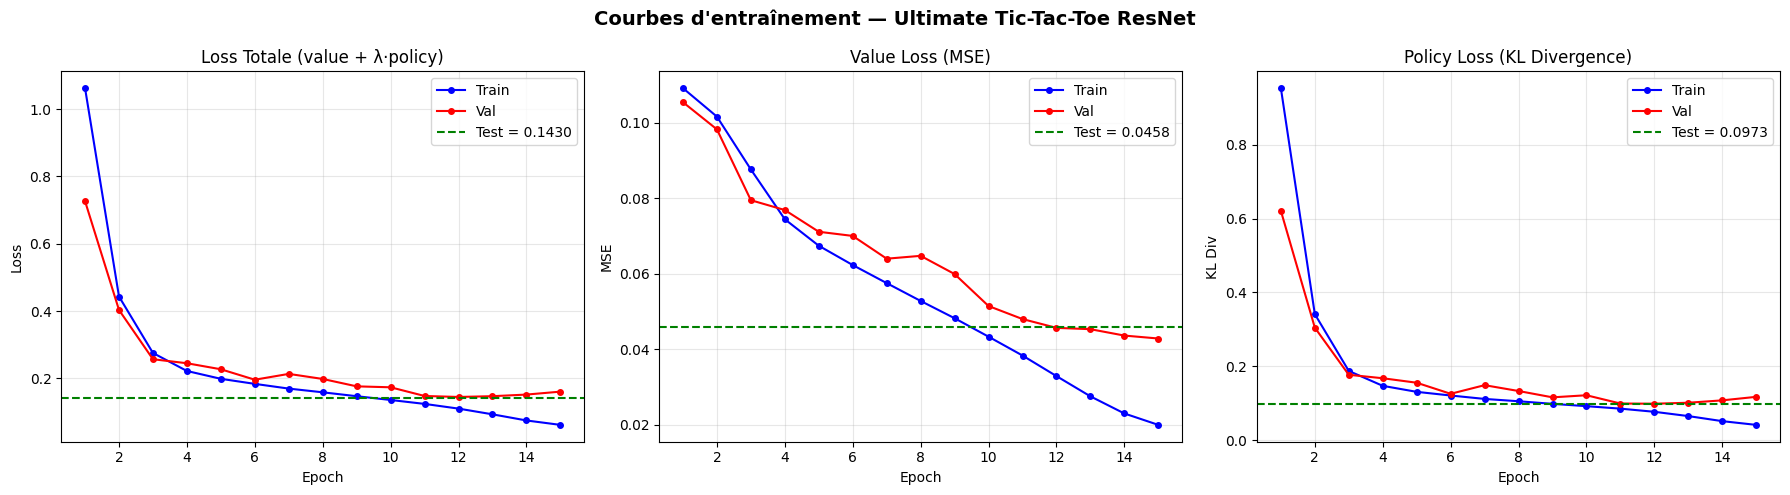

Courbes sauvegardées : training_curves.png


In [9]:
# ============================================================
# 9. VISUALISATION DES COURBES DE LOSS
# ============================================================

epochs_range = range(1, len(history["train_total"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Courbes d'entraînement — Ultimate Tic-Tac-Toe ResNet", fontsize=14, fontweight="bold")

# ── Loss totale ───────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_range, history["train_total"], "b-o", label="Train", markersize=4)
ax.plot(epochs_range, history["val_total"],   "r-o", label="Val",   markersize=4)
ax.axhline(te_total, color="g", linestyle="--", label=f"Test = {te_total:.4f}")
ax.set_title("Loss Totale (value + λ·policy)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Value loss ────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_range, history["train_value"], "b-o", label="Train", markersize=4)
ax.plot(epochs_range, history["val_value"],   "r-o", label="Val",   markersize=4)
ax.axhline(te_val, color="g", linestyle="--", label=f"Test = {te_val:.4f}")
ax.set_title("Value Loss (MSE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Policy loss ───────────────────────────────────────────────
ax = axes[2]
ax.plot(epochs_range, history["train_policy"], "b-o", label="Train", markersize=4)
ax.plot(epochs_range, history["val_policy"],   "r-o", label="Val",   markersize=4)
ax.axhline(te_pol, color="g", linestyle="--", label=f"Test = {te_pol:.4f}")
ax.set_title("Policy Loss (KL Divergence)")
ax.set_xlabel("Epoch")
ax.set_ylabel("KL Div")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Courbes sauvegardées : training_curves.png")

Collecte prédictions:   0%|          | 0/98 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782f4913eb60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/d

── Métriques Value Head (test set) ───────────────
  MSE                  : 0.0458
  MAE                  : 0.1176
  Corrélation Pearson  : 0.7821
  Accuracy directionnelle : 79.5%


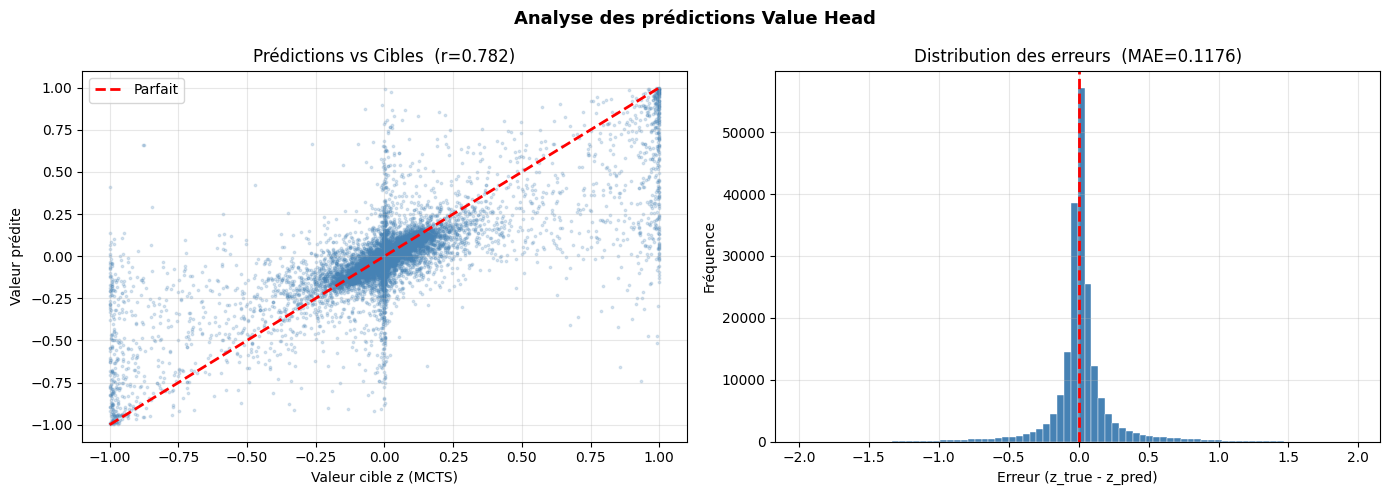

In [10]:
# ============================================================
# 10. ANALYSE DES PRÉDICTIONS
# ============================================================
model.eval()

# Collect predictions
all_z_true, all_z_pred = [], []
with torch.no_grad():
    for x, z, pi in tqdm(test_loader, desc="Collecte prédictions"):
        x = x.to(DEVICE)
        _, v = model(x)
        all_z_true.extend(z.numpy())
        all_z_pred.extend(v.cpu().numpy())

all_z_true = np.array(all_z_true)
all_z_pred = np.array(all_z_pred)

# Métriques
mse  = np.mean((all_z_true - all_z_pred)**2)
mae  = np.mean(np.abs(all_z_true - all_z_pred))
corr = np.corrcoef(all_z_true, all_z_pred)[0, 1]

# Accuracy directionnelle (prédit-on correctement le signe de l'avantage ?)
dir_acc = np.mean(np.sign(all_z_true) == np.sign(all_z_pred))

print("── Métriques Value Head (test set) ───────────────")
print(f"  MSE                  : {mse:.4f}")
print(f"  MAE                  : {mae:.4f}")
print(f"  Corrélation Pearson  : {corr:.4f}")
print(f"  Accuracy directionnelle : {dir_acc*100:.1f}%")

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analyse des prédictions Value Head", fontsize=13, fontweight="bold")

ax = axes[0]
sample_idx = np.random.choice(len(all_z_true), min(10000, len(all_z_true)), replace=False)
ax.scatter(all_z_true[sample_idx], all_z_pred[sample_idx], alpha=0.2, s=3, color="steelblue")
ax.plot([-1, 1], [-1, 1], "r--", linewidth=2, label="Parfait")
ax.set_xlabel("Valeur cible z (MCTS)")
ax.set_ylabel("Valeur prédite")
ax.set_title(f"Prédictions vs Cibles  (r={corr:.3f})")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
errors = all_z_true - all_z_pred
ax.hist(errors, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="red", linestyle="--", linewidth=2)
ax.set_xlabel("Erreur (z_true - z_pred)")
ax.set_ylabel("Fréquence")
ax.set_title(f"Distribution des erreurs  (MAE={mae:.4f})")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("value_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# ============================================================
# 11. TABLEAU RÉCAPITULATIF
# ============================================================

print("\n" + "="*70)
print(" TABLEAU RÉCAPITULATIF FINAL")
print("="*70)
print(f"{'Split':<10} {'Total Loss':>12} {'Value MSE':>12} {'Policy KL':>12}")
print("-"*50)
print(f"{'Train':<10} {history['train_total'][-1]:>12.4f} {history['train_value'][-1]:>12.4f} {history['train_policy'][-1]:>12.4f}")
print(f"{'Val':<10} {history['val_total'][-1]:>12.4f} {history['val_value'][-1]:>12.4f} {history['val_policy'][-1]:>12.4f}")
print(f"{'Test':<10} {te_total:>12.4f} {te_val:>12.4f} {te_pol:>12.4f}")
print("-"*50)
print(f"\nValeur Head — Corrélation Pearson : {corr:.4f}")
print(f"Valeur Head — Accuracy directionnelle : {dir_acc*100:.1f}%")
print(f"\nModèle sauvegardé : {CHECKPOINT_PATH}")
print(f"Paramètres        : {total_params:,} (~{total_params/1e6:.1f}M)")
print(f"Architecture      : {CFG['num_res_blocks']} blocs résiduels × {CFG['num_filters']} filtres")


 TABLEAU RÉCAPITULATIF FINAL
Split        Total Loss    Value MSE    Policy KL
--------------------------------------------------
Train            0.0617       0.0200       0.0418
Val              0.1605       0.0428       0.1177
Test             0.1430       0.0458       0.0973
--------------------------------------------------

Valeur Head — Corrélation Pearson : 0.7821
Valeur Head — Accuracy directionnelle : 79.5%

Modèle sauvegardé : best_uttt_model.pth
Paramètres        : 11,888,538 (~11.9M)
Architecture      : 10 blocs résiduels × 256 filtres
